# **TUẦN 1: 2.1 + 2.2**

In [ ]:
# Cài Java 11 (khuyến nghị cho Spark 3.5.x)
!apt-get update -qq
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

print("Java version:")
!java -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Java version:
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [ ]:
# Cách 2: Tải Spark binary thủ công
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz

import os
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"
!pip install findspark -q
import findspark
findspark.init()

In [ ]:
# Khởi tạo SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Olist_Preprocessing_Week1_Final") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
print("Spark Session đã khởi tạo thành công!")

Spark Session đã khởi tạo thành công!


In [ ]:
!pip install -q streamlit
print("\nStreamlit installed successfully.")


Streamlit installed successfully.


In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip install -q gradio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/datasetCuoiKy/"

In [ ]:
# Đọc dữ liệu
orders_df = spark.read.csv(base_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
customers_df = spark.read.csv(base_path + "olist_customers_dataset.csv", header=True, inferSchema=True)
order_items_df = spark.read.csv(base_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
payments_df = spark.read.csv(base_path + "olist_order_payments_dataset.csv", header=True, inferSchema=True)
reviews_df = spark.read.csv(base_path + "olist_order_reviews_dataset.csv", header=True, inferSchema=True)
products_df = spark.read.csv(base_path + "olist_products_dataset.csv", header=True, inferSchema=True)
sellers_df = spark.read.csv(base_path + "olist_sellers_dataset.csv", header=True, inferSchema=True)
category_df = spark.read.csv(base_path + "product_category_name_translation.csv", header=True, inferSchema=True)
geolocation_df = spark.read.csv(base_path + "olist_geolocation_dataset.csv", header=True, inferSchema=True)
print("Đã đọc xong 9 file CSV")

Đã đọc xong 9 file CSV


In [ ]:
from pyspark.sql.functions import col, sum

def explore_full(df, name):
    print("\n==============================")
    print("DATASET:", name)
    print("==============================")

    # 1. Số dòng
    total_rows = df.count()
    print("Số dòng:", total_rows)

    # 2. Schema
    print("\nSchema:")
    df.printSchema()

    # 3. Dữ liệu mẫu
    print("\n5 dòng đầu:")
    df.show(5, truncate=False)

    # 4. Thống kê mô tả
    print("\nThống kê:")
    df.describe().show()

    # 5. Kiểm tra null
    print("\nSố lượng NULL theo cột:")
    null_df = df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])
    null_df.show()

    # 6. Kiểm tra duplicate
    unique_rows = df.dropDuplicates().count()
    print("\nDuplicate:")
    print("Tổng:", total_rows)
    print("Unique:", unique_rows)
    print("Số dòng trùng:", total_rows - unique_rows)

In [ ]:
explore_full(customers_df, "customers")


DATASET: customers
Số dòng: 99441

Schema:
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|861eff4711a542e4b93843c6dd7febb0|14409                   |franca               |SP            |
|18955e83d337fd6b2def6b18a428ac77|290c77bc529b7ac935b93aa66c333dc3|9790                    |sao bernardo do campo|SP            |
|4e7b3e00288586ebd08712fdd0374a03|060e732b5b29

In [ ]:
explore_full(geolocation_df, "geolocation")


DATASET: geolocation
Số dòng: 1000163

Schema:
root
 |-- geolocation_zip_code_prefix: integer (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)
 |-- geolocation_city: string (nullable = true)
 |-- geolocation_state: string (nullable = true)


5 dòng đầu:
+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|1037                       |-23.54562128115268 |-46.63929204800168|sao paulo       |SP               |
|1046                       |-23.546081127035535|-46.64482029837157|sao paulo       |SP               |
|1046                       |-23.54612896641469 |-46.64295148361138|sao paulo       |SP               |
|1041                       |-23.5443921648681  |-46.63949

In [ ]:
explore_full(order_items_df, "order_items")


DATASET: order_items
Số dòng: 112650

Schema:
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|1            |4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|2017-09-19 09:45:35|58.9 |13.29        |
|00018f77

In [ ]:
explore_full(payments_df, "payments")


DATASET: payments
Số dòng: 103886

Schema:
root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+------------------+------------+--------------------+-------------+
|order_id                        |payment_sequential|payment_type|payment_installments|payment_value|
+--------------------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b1e8b2acac839d17|1                 |credit_card |8                   |99.33        |
|a9810da82917af2d9aefd1278f1dcfa0|1                 |credit_card |1                   |24.39        |
|25e8ea4e93396b6fa0d3dd708e76c1bd|1                 |credit_card |1                   |65.71        |
|ba78997921bbcdc1373bb41e913ab953|1                 |credit_card |8                   |107.7

In [ ]:
explore_full(reviews_df, "reviews")


DATASET: reviews
Số dòng: 104162

Schema:
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-----------------------+
|review_id                       |order_id                        |review_score|review_comment_title|review_comment_message                                                                              |review_creation_date|review_answer_timestamp|
+--------------------------------+--------------------------------+------------+--------------------+---

In [ ]:
explore_full(orders_df, "orders")


DATASET: orders
Số dòng: 99441

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+-

In [ ]:
explore_full(products_df, "products")


DATASET: products
Số dòng: 32951

Schema:
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)


5 dòng đầu:
+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+---------------------+-------------------+---------------------

In [ ]:
explore_full(sellers_df, "sellers")


DATASET: sellers
Số dòng: 3095

Schema:
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+----------------------+-----------------+------------+
|seller_id                       |seller_zip_code_prefix|seller_city      |seller_state|
+--------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|13023                 |campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|13844                 |mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|20031                 |rio de janeiro   |RJ          |
|c0f3eea2e14555b6faeea3dd58c1b1c3|4195                  |sao paulo        |SP          |
|51a04a8a6bdcb23deccc82b0b80742cf|12914                 |braganca paulista|SP          |
+--------------------------------+-----------

In [ ]:
explore_full(category_df, "category_translation")


DATASET: category_translation
Số dòng: 71

Schema:
root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)


5 dòng đầu:
+----------------------+-----------------------------+
|product_category_name |product_category_name_english|
+----------------------+-----------------------------+
|beleza_saude          |health_beauty                |
|informatica_acessorios|computers_accessories        |
|automotivo            |auto                         |
|cama_mesa_banho       |bed_bath_table               |
|moveis_decoracao      |furniture_decor              |
+----------------------+-----------------------------+
only showing top 5 rows


Thống kê:
+-------+---------------------+-----------------------------+
|summary|product_category_name|product_category_name_english|
+-------+---------------------+-----------------------------+
|  count|                   71|                           71|
|   mean|                 NULL|     

# **TUẦN 1: 2.4.Tiền xử lý dữ liệu**

In [ ]:
from pyspark.sql.functions import *

In [ ]:
from pyspark.sql import SparkSession

# Khởi tạo Spark session
spark = SparkSession.builder \
    .appName("Olist_Load_Parquet") \
    .getOrCreate()

# Đường dẫn file
file_path = "/content/drive/MyDrive/datasetCuoiKy/olist_master_processed.parquet"

# Đọc file Parquet
df_master = spark.read.parquet(file_path)

# **IV.4 – Regression**

In [ ]:
from pyspark.sql.functions import col

target_col = "total_payment_value"

df_ml = df_master.filter(col(target_col).isNotNull())

df_ml = df_ml.fillna({
    "total_price": 0,
    "total_freight_value": 0,
    "num_items": 0,
    "product_weight_g": 0,
    "delivery_delay_days": 0,
    "is_late_delivery": 0,
    "product_category_name_english": "unknown",
    "payment_type": "unknown",
    "customer_state": "unknown",
    "seller_state": "unknown"
})

In [ ]:
# Xử lý outlier bằng IQR
q1, q3 = df_ml.approxQuantile(target_col, [0.25, 0.75], 0.05)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_reg = df_ml.filter((col(target_col) >= lower) & (col(target_col) <= upper))
print(f"Số mẫu sau khi lọc outlier: {df_reg.count()}")

Số mẫu sau khi lọc outlier: 89872


In [ ]:
categorical_cols = [
    "payment_type",                    # phương thức thanh toán → hành vi chi tiêu
    "product_category_name_english",   # loại sản phẩm → giá khác nhau
    "customer_state",                  # khu vực khách hàng
    "seller_state"                     # khu vực seller → ảnh hưởng phí ship
]
numeric_cols = [
    "total_price",            # giá sản phẩm → ảnh hưởng trực tiếp payment
    "total_freight_value",    # phí ship → cộng vào payment
    "num_items",              # số lượng → tăng tổng tiền
    "product_weight_g",       # ảnh hưởng phí ship
    "delivery_delay_days",    # trải nghiệm → gián tiếp ảnh hưởng hành vi chi tiêu
    "is_late_delivery"        # giao trễ (0/1)
]

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_vec")
    for c in categorical_cols
]

feature_cols = numeric_cols + [c + "_vec" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"
)

In [ ]:
train_df, test_df = df_reg.randomSplit([0.8, 0.2], seed=42)

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
import time

lr = LinearRegression(
    featuresCol="features",
    labelCol=target_col,
    regParam=0.01,
    elasticNetParam=0.0
)

pipeline_lr = Pipeline(stages=indexers + encoders + [assembler, lr])

start = time.time()
model_lr = pipeline_lr.fit(train_df)
train_time_lr = time.time() - start

pred_lr = model_lr.transform(test_df)

In [ ]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol=target_col,
    maxDepth=5,
    maxBins=32
)

pipeline_dt = Pipeline(stages=indexers + encoders + [assembler, dt])

start = time.time()
model_dt = pipeline_dt.fit(train_df)
train_time_dt = time.time() - start

pred_dt = model_dt.transform(test_df)

In [ ]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target_col,
    numTrees=50,
    maxDepth=10
)

pipeline_rf = Pipeline(stages=indexers + encoders + [assembler, rf])

start = time.time()
model_rf = pipeline_rf.fit(train_df)
train_time_rf = time.time() - start

pred_rf = model_rf.transform(test_df)

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

def eval_reg(pred, name, train_time):
    rmse = RegressionEvaluator(
        labelCol=target_col, predictionCol="prediction", metricName="rmse"
    ).evaluate(pred)

    mae = RegressionEvaluator(
        labelCol=target_col, predictionCol="prediction", metricName="mae"
    ).evaluate(pred)

    r2 = RegressionEvaluator(
        labelCol=target_col, predictionCol="prediction", metricName="r2"
    ).evaluate(pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)
    print("Train time:", train_time)

    return [name, rmse, mae, r2, train_time]

results_reg = []
results_reg.append(eval_reg(pred_lr, "Linear Regression", train_time_lr))
results_reg.append(eval_reg(pred_dt, "Decision Tree", train_time_dt))
results_reg.append(eval_reg(pred_rf, "Random Forest", train_time_rf))


Linear Regression
RMSE: 5.65388846479895
MAE : 0.4903069633662458
R2  : 0.9927337657596089
Train time: 47.99983477592468

Decision Tree
RMSE: 10.28393604010679
MAE : 6.809012456634492
R2  : 0.9759600447879808
Train time: 50.51170468330383

Random Forest
RMSE: 8.834789705259523
MAE : 4.790454070733943
R2  : 0.9822578047923611
Train time: 123.77428483963013


In [ ]:
print(results_reg)

[['Linear Regression', 5.65388846479895, 0.4903069633662458, 0.9927337657596089, 47.99983477592468], ['Decision Tree', 10.28393604010679, 6.809012456634492, 0.9759600447879808, 50.51170468330383], ['Random Forest', 8.834789705259523, 4.790454070733943, 0.9822578047923611, 123.77428483963013]]


In [ ]:
best_result = results_reg[0]

for r in results_reg:
    if r[1] < best_result[1]:
        best_result = r

best_model_name = best_result[0]
print("✅ Best Model:", best_model_name)

✅ Best Model: Linear Regression


In [ ]:
if best_model_name == "Linear Regression":
    best_model = model_lr
elif best_model_name == "Decision Tree":
    best_model = model_dt
elif best_model_name == "Random Forest":
    best_model = model_rf

In [ ]:
import shutil

save_path = "/content/drive/MyDrive/models/best_regression_model"

# Xóa folder cũ nếu có
shutil.rmtree(save_path, ignore_errors=True)

# Lưu PipelineModel
best_model.write().overwrite().save(save_path)

print("✅ Model saved at:", save_path)

✅ Model saved at: /content/drive/MyDrive/models/best_regression_model


In [ ]:
rf_stage = model_rf.stages[-1]
importances = rf_stage.featureImportances.toArray()

# Lấy OneHotEncoderModel
ohe_models = [stage for stage in model_rf.stages if hasattr(stage, "categorySizes")]

ohe_feature_names = []

for col_name, ohe_model in zip(categorical_cols, ohe_models):
    size = ohe_model.categorySizes[0]  # mỗi encoder 1 cột
    for i in range(size - 1):  # FIX dropLast=True
        ohe_feature_names.append(f"{col_name}_{i}")

# Combine với numeric
all_feature_names = numeric_cols + ohe_feature_names

# Map importance
feature_importance = list(zip(all_feature_names, importances))

# Sort
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[1], reverse=True)


In [ ]:
import pandas as pd

# Tạo DataFrame
fi_df = pd.DataFrame(feature_importance_sorted, columns=["Feature", "Importance"])

# Lấy Top 5
top5 = fi_df.head(5)

# In bảng đẹp
print("\nTOP 5 FEATURE IMPORTANCE:")
print(top5.to_string(index=False))


TOP 5 FEATURE IMPORTANCE:
            Feature  Importance
        total_price    0.804754
total_freight_value    0.089839
   product_weight_g    0.067476
          num_items    0.010379
     seller_state_7    0.004569


In [ ]:
import pandas as pd

fi_df = pd.DataFrame(feature_importance_sorted, columns=["Feature", "Importance"])

save_fi_path = "/content/drive/MyDrive/models/feature_importance.csv"
fi_df.to_csv(save_fi_path, index=False)

print("Feature importance saved at:", save_fi_path)

Feature importance saved at: /content/drive/MyDrive/models/feature_importance.csv


Feature importance saved at: /content/drive/MyDrive/models/feature_importance.csv


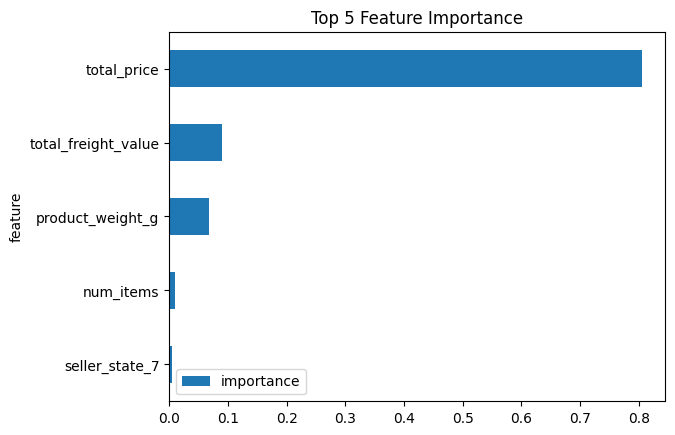

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tạo DataFrame
fi_df = pd.DataFrame(feature_importance_sorted, columns=["feature", "importance"])

# Lấy top 5
top5 = fi_df.head(5)

# Lưu file
save_fi_path = "/content/drive/MyDrive/models/feature_importance.csv"
fi_df.to_csv(save_fi_path, index=False)

print("Feature importance saved at:", save_fi_path)

# Vẽ biểu đồ
top5.plot(kind='barh', x='feature', y='importance')
plt.title("Top 5 Feature Importance")
plt.gca().invert_yaxis()
plt.show()